# Dipole Implementation Comparison

This notebook compares all dipole approximations available in `litebird_sim`, including beam-convolved variants.

The CMB dipole anisotropy arises from the Doppler shift of the monopole temperature due to the motion of the spacecraft. `litebird_sim` provides seven levels of approximation:

| Type | Formula | Notes |
|---|---|---|
| `LINEAR` | $\Delta T = T_0\,b$ | First order in $\beta$ |
| `QUADRATIC_EXACT` | $\Delta T = T_0(b + b^2)$ | Second order, thermodynamic |
| `QUADRATIC_FROM_LIN_T` | $\Delta T = T_0(b + q(x)\,b^2)$ | Second order, linearised |
| `TOTAL_EXACT` | $\Delta T = T_0\sqrt{1-\beta^2}/(1-b) - T_0$ | Exact, thermodynamic |
| `TOTAL_FROM_LIN_T` | Full Planck formula, linearised | Most physically accurate |
| `CUBIC_EXACT` | $\Delta T = T_0(b + b^2 + b^3 - \frac{\beta^2}{2}b)$ | Third order, thermodynamic |
| `CUBIC_FROM_LIN_T` | $\Delta T = T_0(b + q(x)\,b^2 + r(x)\,b^3)$ | Third order, linearised |

where $b = \vec\beta\cdot\hat{n}$, $q(x) = \frac{x(e^x+1)}{2(e^x-1)}$, and $r(x) = \frac{x^2(e^{2x}+4e^x+1)}{6(e^x-1)^2}$.

For the convolved variants (`apply_convolution=True`), beam S-parameters are computed analytically from the beam alms without map synthesis.  `compute_s_params_from_beam_alm` returns a `BeamSParams` object with three fields:

| Field | Shape | Harmonic content | Used for |
|---|---|---|---|
| `s_vec` ($S_i$) | `(3,)` | $\ell=1$ | dipole beam-weighting |
| `s_mat` ($S_{ij}$) | `(3,3)` | $\ell=0,2$ | quadrupole beam-weighting |
| `s_ten` ($S_{ijk}$) | `(3,3,3)` | $\ell=1,3$ | octupole beam-weighting (cubic variants) |

The three currently supported convolved types differ only in their quadrupole weight $q_x$:

| Convolved type | Quadrupole weight $q_x$ |
|---|---|
| `LINEAR` | $0$ (dipole term only) |
| `QUADRATIC_EXACT` | $1$ |
| `QUADRATIC_FROM_LIN_T` | $q(x)$ |


## 1. Setup

Import libraries and reload the `dipole` module to pick up any local changes.

In [11]:
import importlib
import litebird_sim as lbs
import litebird_sim.dipole
importlib.reload(litebird_sim.dipole)
# refresh the public names so lbs.add_dipole_to_observations points to the new code
import litebird_sim as lbs

import numpy as np
import matplotlib.pyplot as plt
import astropy
import astropy.time
from timeit import default_timer as timer

%matplotlib inline

print("LiteBIRD Sim Version:", lbs.__version__)

LiteBIRD Sim Version: 0.16.0


## 2. Simulation Configuration

Choose the IMO version, telescope/channel, mission duration, sampling rate, and beam parameters.
The simulation uses a single LFT detector (`L4-140`, 140 GHz) loaded directly from the PTEP IMO.

In [2]:
# IMO and instrument selection
imo_version = "vPTEP"
telescope = "LFT"
channel = "L4-140"
detlist = ["000_001_017_QB_140_T"]

# Simulation time parameters
start_time = astropy.time.Time("2025-01-01T00:00:00")
mission_duration_days = 1  # Short duration for quick testing

# Sampling rate override (lower than IMO nominal for memory efficiency)
sampling_rate_hz = 10.0  # Hz

# Beam parameters for elliptical Gaussian convolution
ellipticity = 1.3

# Harmonic expansion parameters for beam ALMs
lmax = 512*3
mmax = 4

n_show = 10000

print(f"IMO version:       {imo_version}")
print(f"Telescope/channel: {telescope} / {channel}")
print(f"Detectors:         {detlist}")
print(f"Duration:          {mission_duration_days} days")
print(f"Sampling rate:     {sampling_rate_hz} Hz")
print(f"Beam ellipticity:  {ellipticity}")
print(f"lmax, mmax:        {lmax}, {mmax}")

IMO version:       vPTEP
Telescope/channel: LFT / L4-140
Detectors:         ['000_001_017_QB_140_T']
Duration:          1 days
Sampling rate:     10.0 Hz
Beam ellipticity:  1.3
lmax, mmax:        1536, 4


## 3. Simulation and Pointings

Instantiate the `Simulation` object, load instrument and detector data from the IMO, compute the scanning strategy, create observations, and precompute pointings and spacecraft velocity.

In [3]:
# Load IMO and create simulation
from pylab import dtype
imo = lbs.Imo(flatfile_location=lbs.PTEP_IMO_LOCATION)

sim = lbs.Simulation(
    start_time=start_time,
    duration_s=mission_duration_days * 24 * 3600.0,
    imo=imo,
    description="Dipole implementation comparison",
    random_seed=12345,
)

# Set instrument from IMO
sim.set_instrument(
    lbs.InstrumentInfo.from_imo(
        imo,
        f"/releases/{imo_version}/satellite/{telescope}/instrument_info",
    )
)

# Load detectors from IMO, overriding sampling rate for memory efficiency
dets: list[lbs.DetectorInfo] = []
for n_det in detlist:
    det = lbs.DetectorInfo.from_imo(
        url=f"/releases/{imo_version}/satellite/{telescope}/{channel}/{n_det}/detector_info",
        imo=imo,
    )
    det.sampling_rate_hz = sampling_rate_hz
    dets.append(det)

# Set scanning strategy from IMO
sim.set_scanning_strategy(
    imo_url=f"/releases/{imo_version}/satellite/scanning_parameters/"
)

# Create observations
sim.create_observations(detectors=dets, n_blocks_det=1, n_blocks_time=1, tod_dtype=np.float64)

print(f"Created {len(sim.observations)} observation(s) with {len(dets)} detectors")
print(f"Samples per detector: {sim.observations[0].n_samples:,}")
print(f"Detector names: {[d.name for d in dets]}")
print(f"Detector FWHM: {[round(d.fwhm_arcmin, 2) for d in dets]} arcmin")

Created 1 observation(s) with 1 detectors
Samples per detector: 864,000
Detector names: ['000_001_017_QB_140_T']
Detector FWHM: [23.7] arcmin


In [4]:
# Prepare pointings and spacecraft motion
sim.prepare_pointings()
sim.precompute_pointings()
sim.compute_pos_and_vel()

print("Pointings and spacecraft motion computed")

Pointings and spacecraft motion computed


## 4. Non-Convolved Dipole Comparison

Compute and compare all seven dipole types without beam convolution.
Each implementation is evaluated independently on a zeroed TOD so that timing and RMS are unaffected by the others.

The bottom plot shows residuals with respect to `TOTAL_EXACT`, the most accurate non-convolved formula.

In [5]:
# Test different dipole types without convolution
dipole_types = [
    ("LINEAR",               lbs.DipoleType.LINEAR),
    ("QUADRATIC_EXACT",      lbs.DipoleType.QUADRATIC_EXACT),
    ("QUADRATIC_FROM_LIN_T", lbs.DipoleType.QUADRATIC_FROM_LIN_T),
    ("TOTAL_EXACT",          lbs.DipoleType.TOTAL_EXACT),
    ("TOTAL_FROM_LIN_T",     lbs.DipoleType.TOTAL_FROM_LIN_T),
    ("CUBIC_EXACT",          lbs.DipoleType.CUBIC_EXACT),
    ("CUBIC_FROM_LIN_T",     lbs.DipoleType.CUBIC_FROM_LIN_T),
]

results = {}
print("Testing non-convolved dipole implementations:")
print("-" * 60)

for name, dipole_type in dipole_types:
    # Zero out previous results
    sim.nullify_tod("tod")
    obs_test = sim.observations

    # Add dipole
    start = timer()
    lbs.add_dipole_to_observations(
        observations=obs_test,
        pos_and_vel=sim.pos_and_vel,
        dipole_type=dipole_type,
        component="tod",
    )
    elapsed = timer() - start

    # Copy TOD values (not references) so they survive the next nullify_tod call
    tod_values = [obs.tod.copy() for obs in obs_test]
    tod_rms = [np.std(tod) for tod in tod_values]
    tod_mean = [np.mean(tod) for tod in tod_values]

    results[name] = {
        "type": dipole_type,
        "time": elapsed,
        "rms": tod_rms,
        "mean": tod_mean,
        "tods": tod_values,
    }

    print(f"{name:25s}: RMS={np.mean(tod_rms):10.3e} K, Mean={np.mean(tod_mean):10.3e} K, Time={elapsed:.3f}s")

print("-" * 60)

Testing non-convolved dipole implementations:
------------------------------------------------------------
LINEAR                   : RMS= 2.018e-03 K, Mean= 4.507e-04 K, Time=0.620s
QUADRATIC_EXACT          : RMS= 2.018e-03 K, Mean= 4.522e-04 K, Time=0.014s
QUADRATIC_FROM_LIN_T     : RMS= 2.018e-03 K, Mean= 4.530e-04 K, Time=0.014s
TOTAL_EXACT              : RMS= 2.018e-03 K, Mean= 4.498e-04 K, Time=0.013s
TOTAL_FROM_LIN_T         : RMS= 2.018e-03 K, Mean= 4.506e-04 K, Time=0.015s
CUBIC_EXACT              : RMS= 2.018e-03 K, Mean= 4.522e-04 K, Time=0.013s
CUBIC_FROM_LIN_T         : RMS= 2.018e-03 K, Mean= 4.530e-04 K, Time=0.014s
------------------------------------------------------------


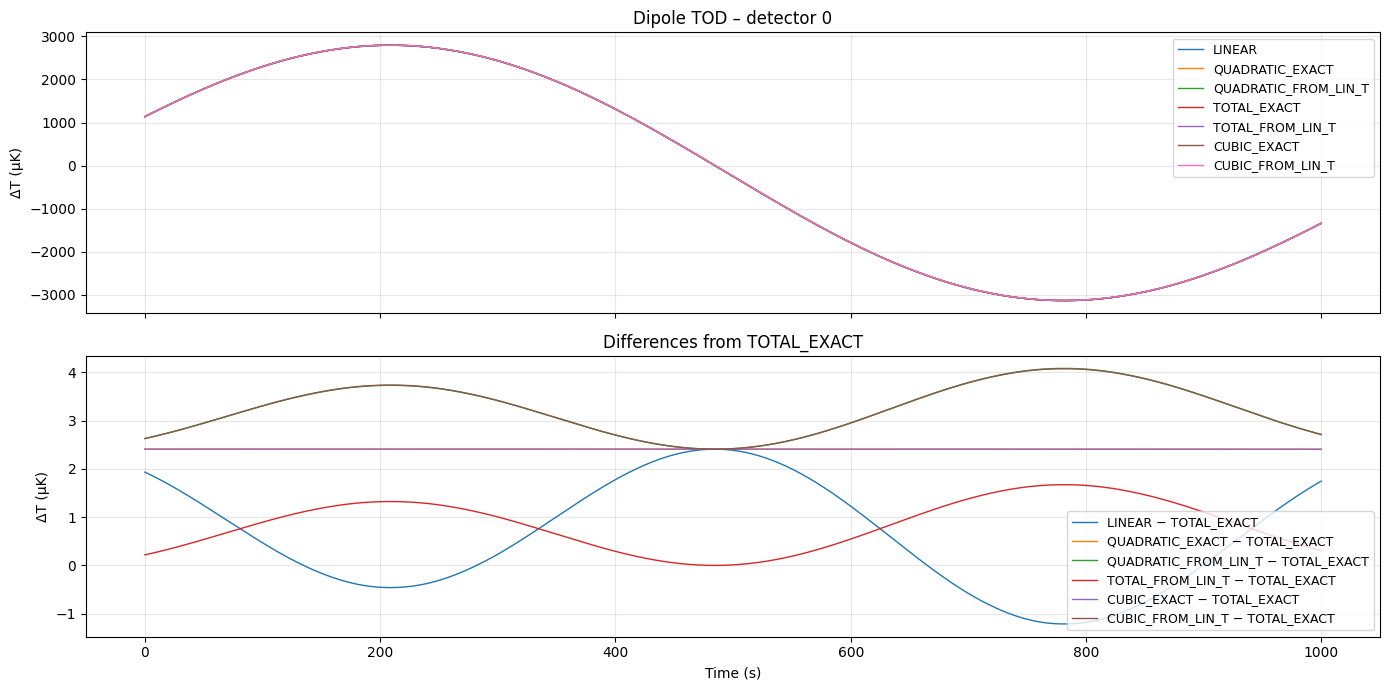

In [6]:
# Time axis (seconds)
t = np.arange(sim.observations[0].n_samples) / sampling_rate_hz

# Extract detector-0 TOD for each implementation
tods = {name: res["tods"][0][0] for name, res in results.items()}
ref = tods["TOTAL_EXACT"]

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# --- top panel: all timelines ---
ax = axes[0]
for name, tod in tods.items():
    ax.plot(t[:n_show], tod[:n_show] * 1e6, label=name, linewidth=1)
ax.set_ylabel("ΔT (µK)")
ax.legend(fontsize=9)
ax.set_title("Dipole TOD – detector 0")
ax.grid(True, alpha=0.3)

# --- bottom panel: differences from TOTAL_EXACT ---
ax = axes[1]
for name, tod in tods.items():
    if name == "TOTAL_EXACT":
        continue
    ax.plot(t[:n_show], (tod - ref)[:n_show] * 1e6, label=f"{name} − TOTAL_EXACT", linewidth=1)
ax.set_ylabel("ΔT (µK)")
ax.set_xlabel("Time (s)")
ax.legend(fontsize=9)
ax.set_title("Differences from TOTAL_EXACT")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Beam-Convolved Dipole Comparison

Build an elliptical Gaussian beam in harmonic space with `gauss_beam_to_alm`, then run the three beam-convolved dipole variants.

`compute_s_params_from_beam_alm` extracts all three beam-moment tensors analytically from the alms:

$$S_i = \int B\,\hat{n}_i\,d\Omega \quad S_{ij} = \int B\,\hat{n}_i\hat{n}_j\,d\Omega \quad S_{ijk} = \int B\,\hat{n}_i\hat{n}_j\hat{n}_k\,d\Omega$$

Only $\ell\le3$ alm coefficients contribute (by parity and degree), so no map synthesis is needed.  The three convolved types below share the same fast S-params path and differ only in the quadrupole weight $q_x$:
- **`LINEAR` (conv)**: $q_x = 0$ — beam-weighted dipole term only.
- **`QUADRATIC_EXACT` (conv)**: $q_x = 1$ — thermodynamic quadrupole correction.
- **`QUADRATIC_FROM_LIN_T` (conv)**: $q_x(x) = \frac{x(e^x+1)}{2(e^x-1)}$ — linearised quadrupole correction.

The octupole tensor `s_ten` ($S_{ijk}$) is now fully computed (see Section 7) and will be used by future cubic-order convolved variants.  The sample loop is parallelised with Numba `prange`; computation is O(1) per sample after the one-time S-params setup.


In [7]:
# Build beam ALMs (elliptical Gaussian, FWHM from IMO)
from litebird_sim.beam_synthesis import gauss_beam_to_alm

fwhm_rad = dets[0].fwhm_arcmin * lbs.constants.ARCMIN_TO_RAD
beam_alm = gauss_beam_to_alm(
    lmax=lmax, mmax=mmax, fwhm_rad=fwhm_rad,
    ellipticity=ellipticity, psi_ell_rad=0.0, psi_pol_rad=0.0,
)
# dict keyed by detector index (string) as expected by add_dipole_to_observations
beam_alms = {str(i): beam_alm for i in range(len(dets))}
print(f"Beam ALM shape: {beam_alm.values.shape}, FWHM={dets[0].fwhm_arcmin:.1f} arcmin, ellipticity={ellipticity}")

Beam ALM shape: (3, 7675), FWHM=23.7 arcmin, ellipticity=1.3


Testing convolved dipole implementations:
------------------------------------------------------------
LINEAR (conv)                      : RMS= 2.018e-03 K, Mean= 4.507e-04 K, Time=0.486s
QUADRATIC_EXACT (conv)             : RMS= 2.018e-03 K, Mean= 4.522e-04 K, Time=0.017s
QUADRATIC_FROM_LIN_T (conv)        : RMS= 2.018e-03 K, Mean= 4.530e-04 K, Time=0.015s
------------------------------------------------------------


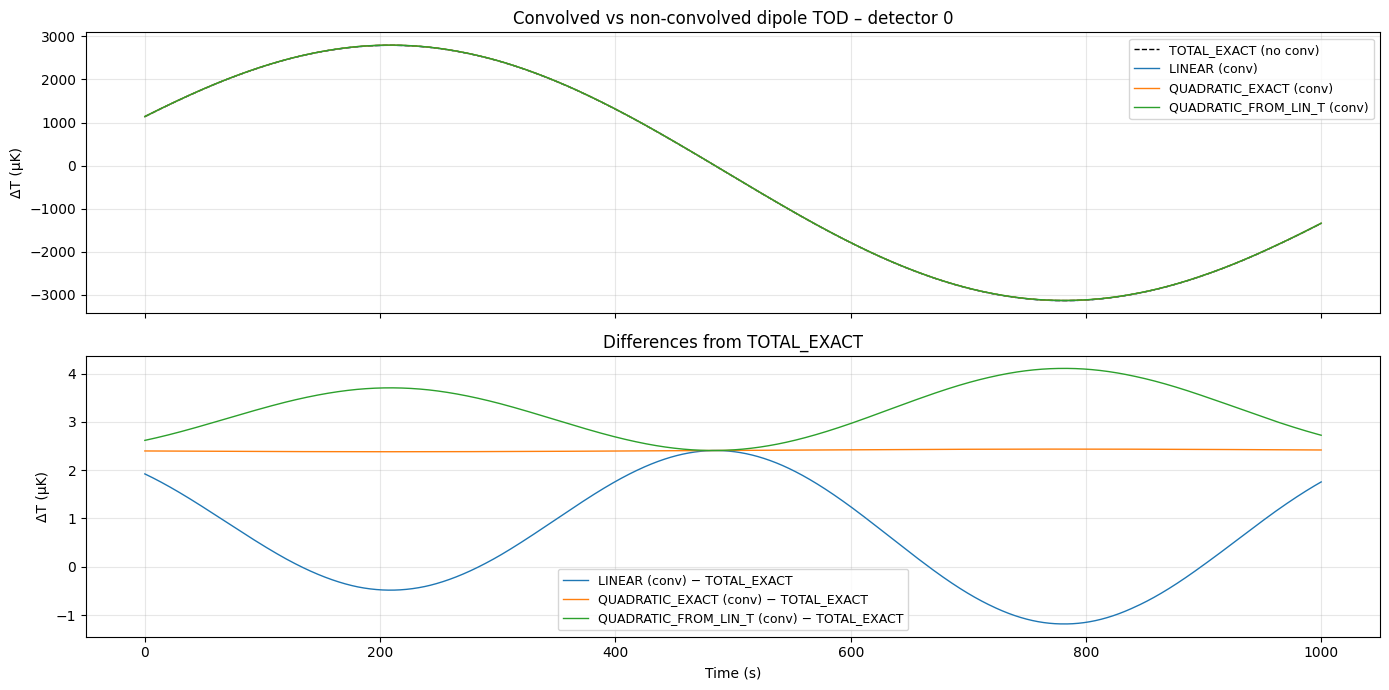

In [12]:
# Convolved dipole types
conv_types = [
    ("LINEAR (conv)",               lbs.DipoleType.LINEAR),
    ("QUADRATIC_EXACT (conv)",      lbs.DipoleType.QUADRATIC_EXACT),
    ("QUADRATIC_FROM_LIN_T (conv)", lbs.DipoleType.QUADRATIC_FROM_LIN_T),
]

conv_results = {}
print("Testing convolved dipole implementations:")
print("-" * 60)

for name, dipole_type in conv_types:
    sim.nullify_tod("tod")
    start = timer()
    lbs.add_dipole_to_observations(
        observations=sim.observations,
        pos_and_vel=sim.pos_and_vel,
        dipole_type=dipole_type,
        component="tod",
        apply_convolution=True,
        beam_alms=beam_alms,
    )
    elapsed = timer() - start
    tod_copy = [obs.tod.copy() for obs in sim.observations]
    rms = [np.std(t) for t in tod_copy]
    mean = [np.mean(t) for t in tod_copy]
    conv_results[name] = {"time": elapsed, "rms": rms, "mean": mean, "tods": tod_copy}
    print(f"{name:35s}: RMS={np.mean(rms):10.3e} K, Mean={np.mean(mean):10.3e} K, Time={elapsed:.3f}s")

print("-" * 60)

# ---------- compare convolved vs non-convolved (TOTAL_EXACT reference) ----------
t = np.arange(sim.observations[0].n_samples) / sampling_rate_hz
ref_noconv = results["TOTAL_EXACT"]["tods"][0][0]

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ax = axes[0]
ax.plot(t[:n_show], ref_noconv[:n_show] * 1e6, label="TOTAL_EXACT (no conv)", linewidth=1, color="k", linestyle="--")
for name, res in conv_results.items():
    ax.plot(t[:n_show], res["tods"][0][0][:n_show] * 1e6, label=name, linewidth=1)
ax.set_ylabel("ΔT (µK)")
ax.legend(fontsize=9)
ax.set_title("Convolved vs non-convolved dipole TOD – detector 0")
ax.grid(True, alpha=0.3)

ax = axes[1]
for name, res in conv_results.items():
    tod_conv = res["tods"][0][0]
    ax.plot(t[:n_show], (tod_conv - ref_noconv)[:n_show] * 1e6, label=f"{name} − TOTAL_EXACT", linewidth=1)
ax.set_ylabel("ΔT (µK)")
ax.set_xlabel("Time (s)")
ax.legend(fontsize=9)
ax.set_title("Differences from TOTAL_EXACT")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Convolution Effect on QUADRATIC_FROM_LIN_T

Isolate the convolution correction for `QUADRATIC_FROM_LIN_T` by differencing the convolved and non-convolved timelines.
For a nearly symmetric beam (ellipticity 1.3, FWHM ≈ 24') the effect is at the **~0.03 µK** level — three orders of magnitude below the dipole signal — because the off-boresight beam moments $S_x$, $S_y$ are small and the quadrupole correction $S_{ij}\beta_i\beta_j$ is second order in $\beta \sim 10^{-3}$.

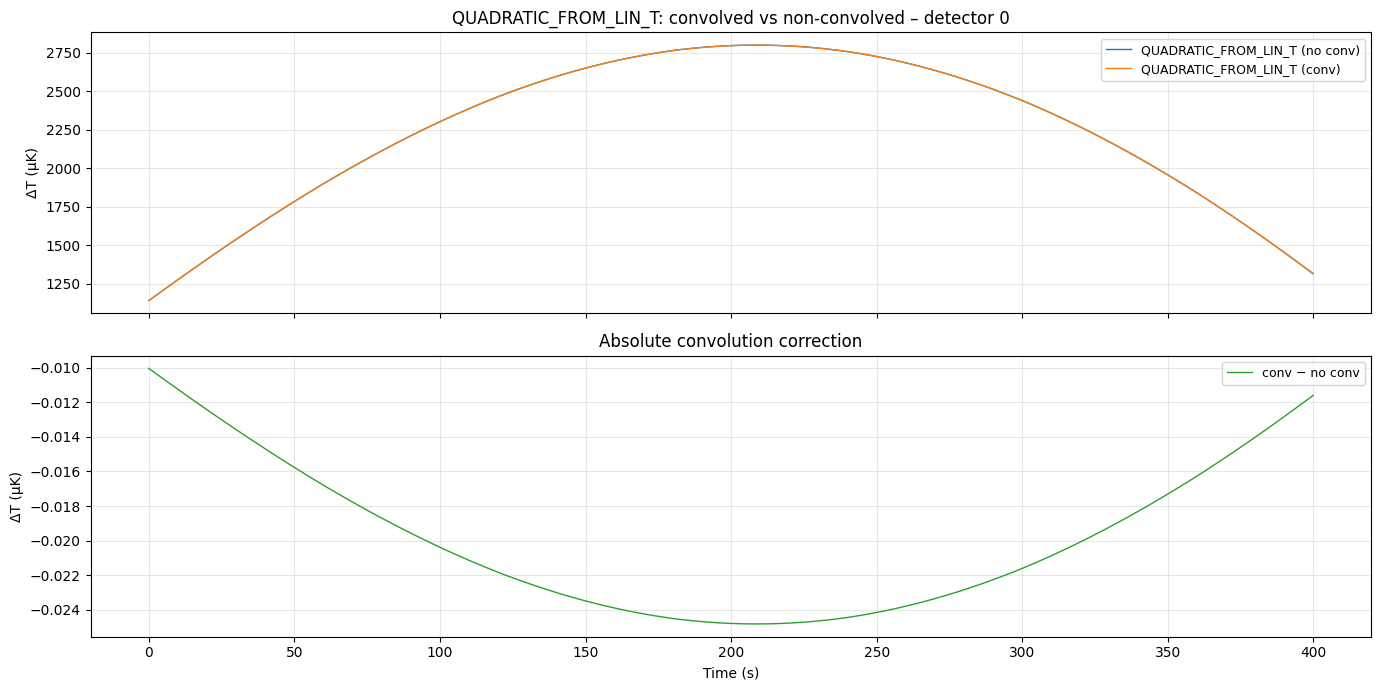

In [ ]:
quad_noconv = results["QUADRATIC_FROM_LIN_T"]["tods"][0][0]
quad_conv   = conv_results["QUADRATIC_FROM_LIN_T (conv)"]["tods"][0][0]

diff  = quad_conv - quad_noconv
# mask samples where the signal is too close to zero (< 1 % of its RMS)
signal_rms = np.std(quad_noconv)
valid = np.abs(quad_noconv) > 0.01 * signal_rms
ratio = np.where(valid, diff / quad_noconv, np.nan)

n_400s = int(400 * sampling_rate_hz)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ax = axes[0]
ax.plot(t[:n_400s], quad_noconv[:n_400s] * 1e6, label="QUADRATIC_FROM_LIN_T (no conv)", linewidth=1)
ax.plot(t[:n_400s], quad_conv[:n_400s]   * 1e6, label="QUADRATIC_FROM_LIN_T (conv)",    linewidth=1)
ax.set_ylabel("ΔT (µK)")
ax.legend(fontsize=9)
ax.set_title("QUADRATIC_FROM_LIN_T: convolved vs non-convolved – detector 0")
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(t[:n_400s], diff[:n_400s] * 1e6, label="conv − no conv", linewidth=1, color="C2")
ax.set_ylabel("ΔT (µK)")
ax.set_xlabel("Time (s)")
ax.legend(fontsize=9)
ax.set_title("Absolute convolution correction")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

s_vec  = [-0.000000e+00, 0.000000e+00, 0.9999911323]
sz - 1 = -8.8677e-06  (-8.868 × 10⁻⁶)
sqrt(C_1 / C_0) = 0.9999911323
1 - sqrt(C_1/C_0) = 8.8677e-06  (8.868 × 10⁻⁶)


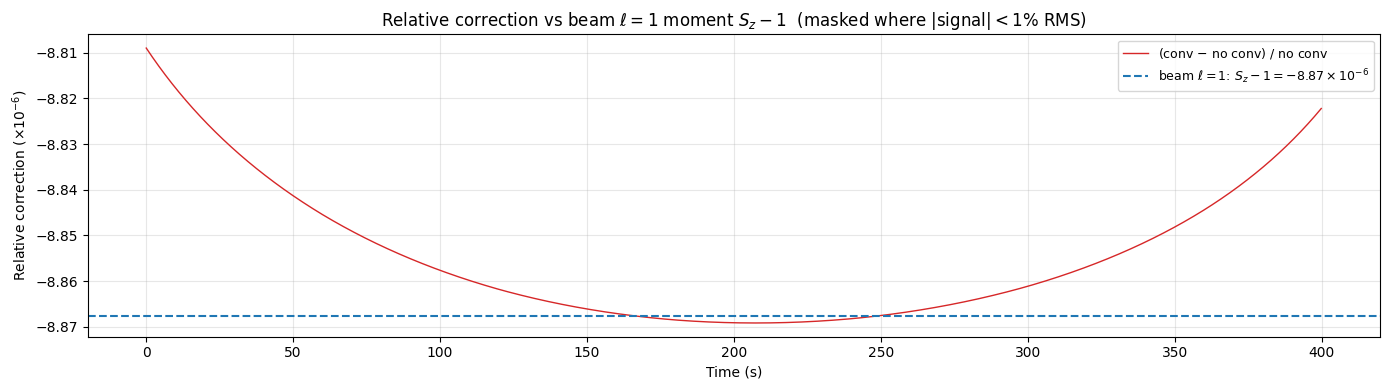

In [ ]:
import litebird_sim.dipole as lbs_dipole

# Beam l=1 moment via S-params
s_params = lbs_dipole.compute_s_params_from_beam_alm(beam_alm)
sx, sy, sz = s_params.s_vec
print(f"s_vec  = [{sx:.6e}, {sy:.6e}, {sz:.10f}]")
print(f"sz - 1 = {sz - 1.0:.4e}  ({(sz - 1.0)*1e6:.3f} × 10⁻⁶)")

# Cross-check: l=1 power directly from alm coefficients
#   m-major ordering: index 1 → (l=1, m=0),  lmax+1 → (l=1, m=1)
#   For this beam the even-m-only loop leaves a_{1,1} = 0
alm_t = beam_alm.values[0]
a00 = float(np.real(alm_t[0]))
a10 = float(np.real(alm_t[1]))
a11 = complex(alm_t[beam_alm.lmax + 1])
C0 = a00**2
C1 = (a10**2 + 2.0 * np.abs(a11)**2) / 3.0
print(f"sqrt(C_1 / C_0) = {np.sqrt(C1/C0):.10f}")
print(f"1 - sqrt(C_1/C_0) = {1 - np.sqrt(C1/C0):.4e}  ({(1 - np.sqrt(C1/C0))*1e6:.3f} × 10⁻⁶)")

beam_l1_level = (sz - 1.0) * 1e6   # in units of × 10⁻⁶

fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(t[:n_400s], ratio[:n_400s] * 1e6,
        label=r"(conv $-$ no conv) / no conv", linewidth=1, color="C3")
ax.axhline(beam_l1_level, color="C0", linestyle="--", linewidth=1.5,
           label=rf"beam $\ell=1$: $S_z - 1 = {beam_l1_level:.2f}\times10^{{-6}}$")

ax.set_ylabel(r"Relative correction ($\times 10^{-6}$)")
ax.set_xlabel("Time (s)")
ax.legend(fontsize=9)
ax.set_title(r"Relative correction vs beam $\ell=1$ moment $S_z-1$  "
             r"(masked where $|\mathrm{signal}| < 1\%$ RMS)")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Summary Comparison: All Dipole Types

Two-panel overview of all implemented approximations:

- **Top panel** — residuals from `TOTAL_EXACT` for each non-convolved type, showing how the polynomial expansions converge to the exact formula.  `TOTAL_FROM_LIN_T` differs from `TOTAL_EXACT` only due to the change of units (thermodynamic vs linearised-$T$); the cubic variants sit within a few µK of the exact result.
- **Bottom panel** — beam-convolution correction for the three supported convolved types (convolved minus its non-convolved counterpart).  The effect is at the **~0.03 µK** level for this beam (ellipticity 1.3, FWHM ≈ 24′).


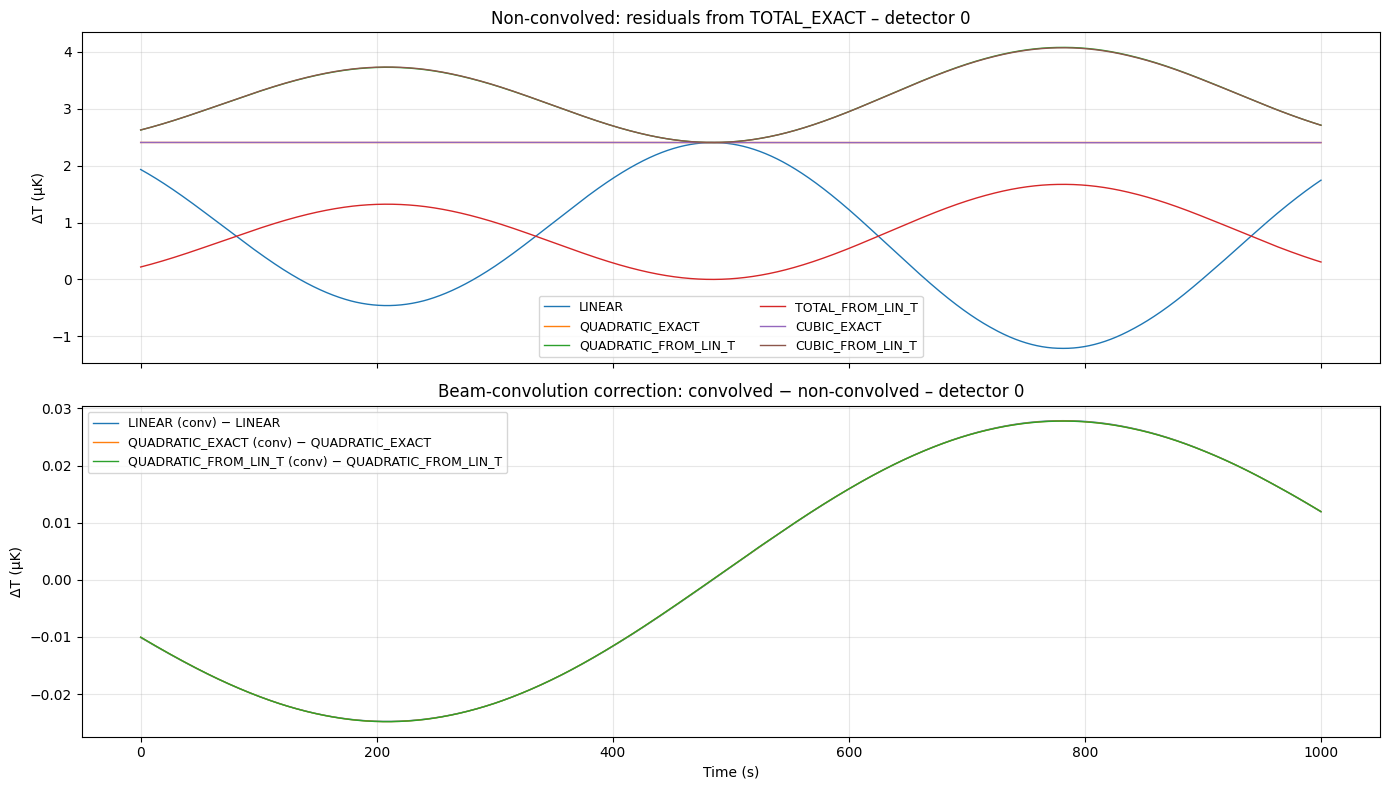

In [13]:
t_ax = np.arange(sim.observations[0].n_samples) / sampling_rate_hz
ref_te = results["TOTAL_EXACT"]["tods"][0][0]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# --- top: non-convolved residuals from TOTAL_EXACT ---
ax = axes[0]
for name, res in results.items():
    if name == "TOTAL_EXACT":
        continue
    tod = res["tods"][0][0]
    ax.plot(t_ax[:n_show], (tod - ref_te)[:n_show] * 1e6, label=name, linewidth=1)
ax.set_ylabel("ΔT (µK)")
ax.legend(fontsize=9, ncol=2)
ax.set_title("Non-convolved: residuals from TOTAL_EXACT – detector 0")
ax.grid(True, alpha=0.3)

# --- bottom: beam-convolution correction (convolved − non-convolved) ---
ax = axes[1]
conv_name_map = {
    "LINEAR (conv)":               "LINEAR",
    "QUADRATIC_EXACT (conv)":      "QUADRATIC_EXACT",
    "QUADRATIC_FROM_LIN_T (conv)": "QUADRATIC_FROM_LIN_T",
}
for conv_name, base_name in conv_name_map.items():
    tod_conv = conv_results[conv_name]["tods"][0][0]
    tod_base = results[base_name]["tods"][0][0]
    ax.plot(t_ax[:n_show], (tod_conv - tod_base)[:n_show] * 1e6,
            label=f"{conv_name} − {base_name}", linewidth=1)
ax.set_ylabel("ΔT (µK)")
ax.set_xlabel("Time (s)")
ax.legend(fontsize=9)
ax.set_title("Beam-convolution correction: convolved − non-convolved – detector 0")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
